In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.stats import jarque_bera # For normality test


print("Packages loaded successfully.")

Packages loaded successfully.


In [2]:
tickers = ["AAPL", "MSFT", "JPM", "JNJ", "XOM", "KO", "BA", "GE", "NEE", "T"] # List of 10 major S&P 500 companies' ticker symbols

prices = yf.download(
    tickers,
    start="2010-01-01",
    end="2024-12-31",
    auto_adjust=False,
    progress=False # Disable download progress bar for cleaner output
)["Close"]

prices.head()

Ticker,AAPL,BA,GE,JNJ,JPM,KO,MSFT,NEE,T,XOM
Date,,,,,,,,,,
2010-01-04,7.643214,56.180000,74.043159,64.680000,42.849998,28.520000,30.950001,13.3125,21.586103,69.150002
2010-01-05,7.656429,58.020000,74.426552,63.930000,43.680000,28.174999,30.959999,13.1825,21.480364,69.419998
2010-01-06,7.534643,59.779999,74.043159,64.449997,43.919998,28.165001,30.770000,13.3125,20.853474,70.019997
2010-01-07,7.520714,62.200001,77.877106,63.990002,44.790001,28.094999,30.450001,13.2750,20.619335,69.800003
2010-01-08,7.570714,61.599998,79.554459,64.209999,44.680000,27.575001,30.660000,13.1600,20.468279,69.519997


In [3]:
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

log_returns.head()

Ticker,AAPL,BA,GE,JNJ,JPM,KO,MSFT,NEE,T,XOM
Date,,,,,,,,,,
2010-01-05,0.001727,0.032227,0.005165,-0.011663,0.019185,-0.012171,0.000323,-0.009813,-0.004911,0.003897
2010-01-06,-0.016034,0.029883,-0.005165,0.008101,0.005479,-0.000355,-0.006156,0.009813,-0.029619,0.008606
2010-01-07,-0.001850,0.039684,0.050484,-0.007163,0.019615,-0.002489,-0.010454,-0.002821,-0.011291,-0.003147
2010-01-08,0.006626,-0.009693,0.021310,0.003432,-0.002459,-0.018682,0.006873,-0.008701,-0.007353,-0.004020
2010-01-11,-0.008861,-0.011921,0.009592,0.000156,-0.003363,0.020105,-0.012802,-0.000760,-0.004809,0.011157


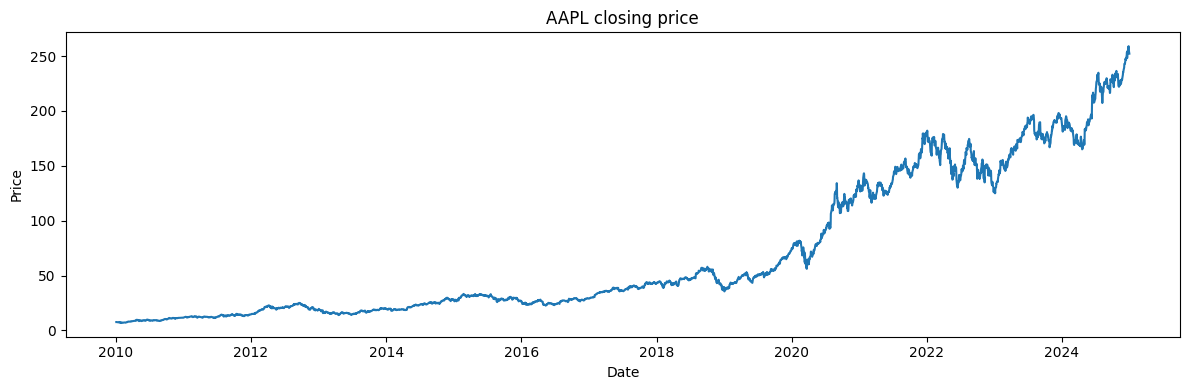

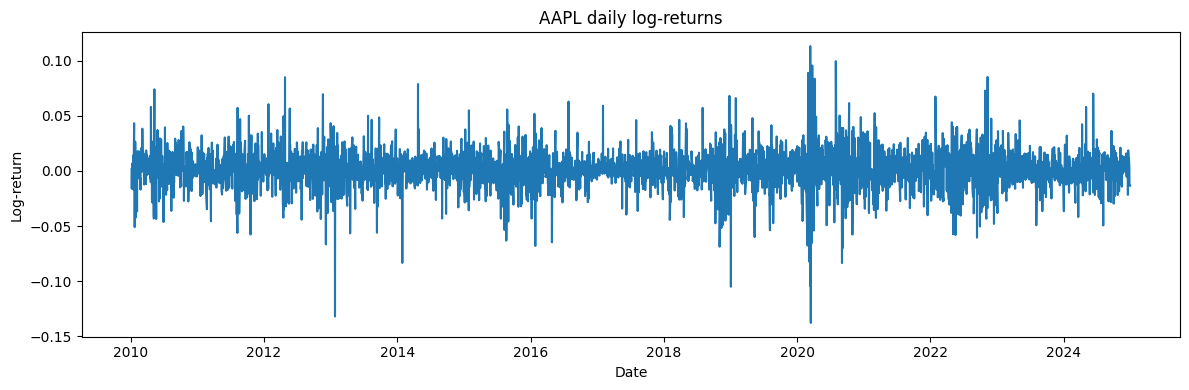

In [4]:
stock = "AAPL"

plt.figure(figsize=(12, 4))
plt.plot(prices.index, prices[stock])
plt.title(f"{stock} closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, log_returns[stock])
plt.title(f"{stock} daily log-returns")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.tight_layout()
plt.show()

In [5]:
summary_rows = []

for ticker in tickers:
    r = log_returns[ticker].dropna()

    mean_return = r.mean() * 100
    std_return = r.std() * 100
    lag1_autocorr = r.autocorr(lag=1)
    squared_return_autocorr = (r ** 2).autocorr(lag=1)
    kurtosis = r.kurtosis()

    jb_result = jarque_bera(r)
    jb_pvalue = jb_result.pvalue

    summary_rows.append({
        "Stock": ticker,
        "Mean (%)": mean_return,
        "Std. dev. (%)": std_return,
        "Lag-1 autocorr.": lag1_autocorr,
        "Sq. return autocorr.": squared_return_autocorr,
        "Kurtosis": kurtosis,
        "JB p-value": jb_pvalue
    })

summary_table = pd.DataFrame(summary_rows)

summary_table

,Stock,Mean (%),Std. dev. (%),Lag-1 autocorr.,Sq. return autocorr.,Kurtosis,JB p-value
0,AAPL,0.092694,1.756964,-0.038233,0.218275,5.438630,0.0
1,MSFT,0.069441,1.612892,-0.103430,0.376043,7.990932,0.0
2,JPM,0.045602,1.748606,-0.098085,0.393804,9.641139,0.0
3,JNJ,0.021097,1.056909,-0.063936,0.284798,9.239396,0.0
4,XOM,0.011264,1.580865,-0.025472,0.204715,7.141185,0.0
5,KO,0.020599,1.079962,-0.030906,0.236363,9.456659,0.0
6,BA,0.030356,2.262037,0.048073,0.347246,19.364185,0.0
7,GE,0.021737,1.978990,-0.017025,0.268024,7.203915,0.0
8,NEE,0.044661,1.386907,-0.046934,0.231127,11.316063,0.0
9,T,0.001229,1.315873,-0.038723,0.259855,8.433306,0.0


In [6]:
summary_table_rounded = summary_table.copy()

summary_table_rounded["Mean (%)"] = summary_table_rounded["Mean (%)"].round(2)
summary_table_rounded["Std. dev. (%)"] = summary_table_rounded["Std. dev. (%)"].round(2)
summary_table_rounded["Lag-1 autocorr."] = summary_table_rounded["Lag-1 autocorr."].round(2)
summary_table_rounded["Sq. return autocorr."] = summary_table_rounded["Sq. return autocorr."].round(2)
summary_table_rounded["Kurtosis"] = summary_table_rounded["Kurtosis"].round(1)
summary_table_rounded["JB p-value"] = summary_table_rounded["JB p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else round(x, 3)
)

summary_table_rounded

,Stock,Mean (%),Std. dev. (%),Lag-1 autocorr.,Sq. return autocorr.,Kurtosis,JB p-value
0,AAPL,0.09,1.76,-0.04,0.22,5.4,<0.001
1,MSFT,0.07,1.61,-0.10,0.38,8.0,<0.001
2,JPM,0.05,1.75,-0.10,0.39,9.6,<0.001
3,JNJ,0.02,1.06,-0.06,0.28,9.2,<0.001
4,XOM,0.01,1.58,-0.03,0.20,7.1,<0.001
5,KO,0.02,1.08,-0.03,0.24,9.5,<0.001
6,BA,0.03,2.26,0.05,0.35,19.4,<0.001
7,GE,0.02,1.98,-0.02,0.27,7.2,<0.001
8,NEE,0.04,1.39,-0.05,0.23,11.3,<0.001
9,T,0.00,1.32,-0.04,0.26,8.4,<0.001


In [7]:
summary_table_rounded.to_csv("../reports/tables/preliminary_eda_summary.csv", index=False)

print("Saved table to reports/tables/preliminary_eda_summary.csv")

Saved table to reports/tables/preliminary_eda_summary.csv


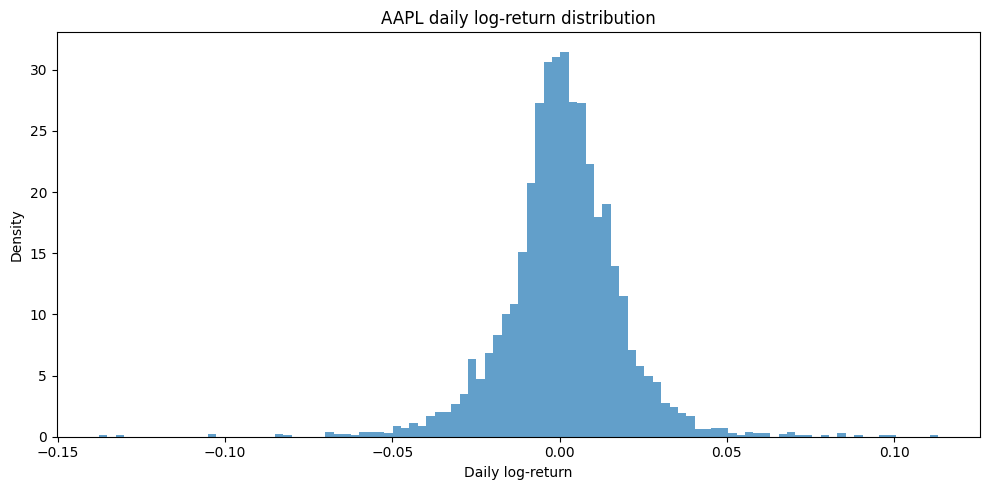

In [8]:
stock = "AAPL"
r = log_returns[stock].dropna()

plt.figure(figsize=(10, 5))
plt.hist(r, bins=100, density=True, alpha=0.7)
plt.title(f"{stock} daily log-return distribution")
plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

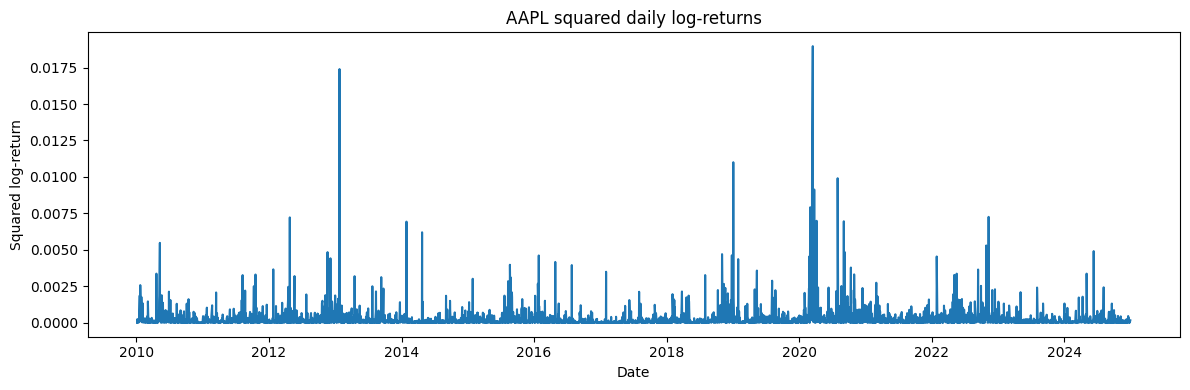

In [9]:
stock = "AAPL"

plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, log_returns[stock] ** 2)
plt.title(f"{stock} squared daily log-returns")
plt.xlabel("Date")
plt.ylabel("Squared log-return")
plt.tight_layout()
plt.show()

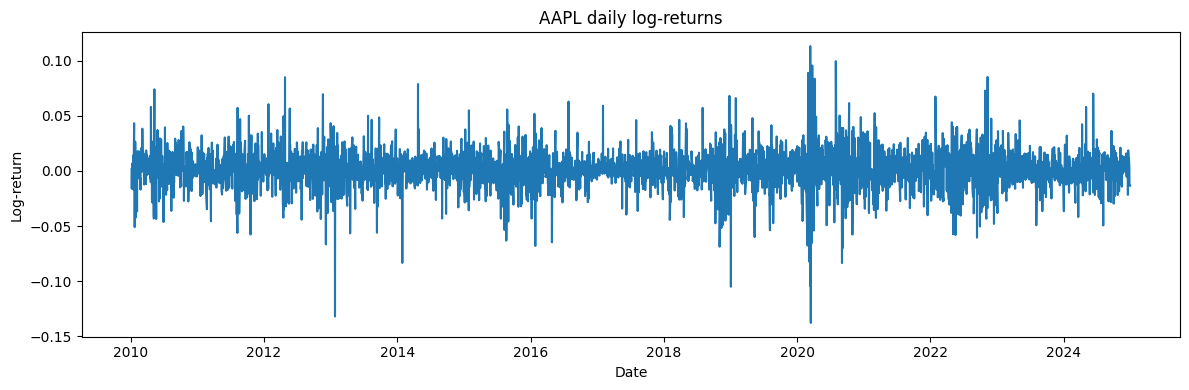

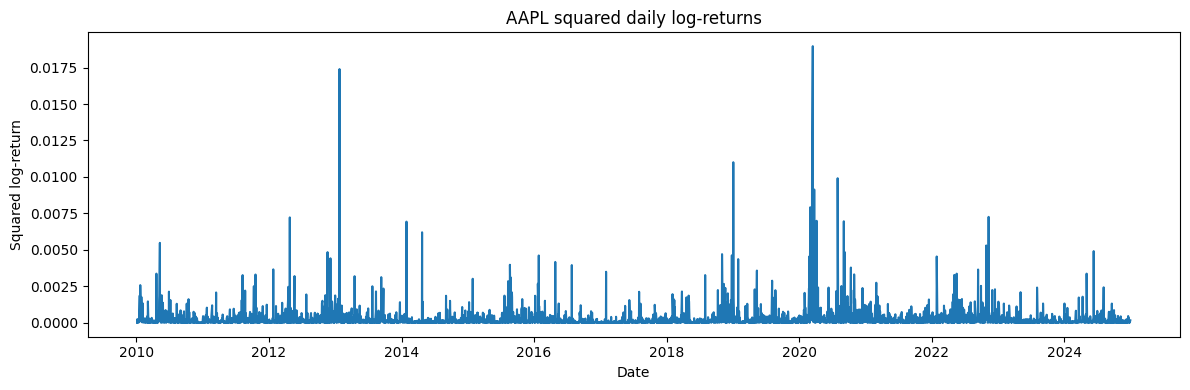

In [10]:
stock = "AAPL"

plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, log_returns[stock])
plt.title(f"{stock} daily log-returns")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.tight_layout()
plt.savefig("../reports/figures/aapl_log_returns.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, log_returns[stock] ** 2)
plt.title(f"{stock} squared daily log-returns")
plt.xlabel("Date")
plt.ylabel("Squared log-return")
plt.tight_layout()
plt.savefig("../reports/figures/aapl_squared_returns.png", dpi=150)
plt.show()